<a href="https://colab.research.google.com/github/TanVi3001/drosophila-pd-flygym/blob/main/FlyBrain_Session01_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SESSION 1 — SETUP + KIỂM TRA FLYGYM 2.1.0

### BLOCK 1 — Google Colab + GPU + EGL

### Chạy nguyên block này trước tất cả những block khác:

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 1
# GOOGLE COLAB + GPU + EGL SETUP
# ============================================================

import os
import sys

print("=" * 70)
print("SESSION 1 — BLOCK 1")
print("GOOGLE COLAB + GPU + EGL SETUP")
print("=" * 70)

# ------------------------------------------------------------
# Check Colab
# ------------------------------------------------------------

if "google.colab" not in sys.modules:
    raise RuntimeError(
        "This session is intended to run in Google Colab."
    )

print("Google Colab: YES ✅")

# ------------------------------------------------------------
# Headless rendering
# ------------------------------------------------------------

os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

print("MUJOCO_GL:", os.environ["MUJOCO_GL"])
print("PYOPENGL_PLATFORM:", os.environ["PYOPENGL_PLATFORM"])

# ------------------------------------------------------------
# GPU
# ------------------------------------------------------------

print("\n=== GPU CHECK ===")

!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader

print("\nGPU setup block complete ✅")

SESSION 1 — BLOCK 1
GOOGLE COLAB + GPU + EGL SETUP
Google Colab: YES ✅
MUJOCO_GL: egl
PYOPENGL_PLATFORM: egl

=== GPU CHECK ===
Tesla T4, 15360 MiB, 580.82.07

GPU setup block complete ✅


## BLOCK 2 — Cài đúng FlyGym 2.1.0

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 2
# INSTALL FLYGYM 2.1.0
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 2")
print("INSTALLING FLYGYM 2.1.0")
print("=" * 70)

%pip install -q --upgrade pip

%pip install -q \
    "flygym @ git+https://github.com/NeLy-EPFL/flygym.git@v2.1.0" \
    tqdm

print("\nFlyGym 2.1.0 installation command completed ✅")

SESSION 1 — BLOCK 2
INSTALLING FLYGYM 2.1.0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

FlyGym 2.1.0 installation command completed ✅


## BLOCK 3 — Kiểm tra API mới

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 3
# VERIFY FLYGYM API
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 3")
print("VERIFYING FLYGYM API")
print("=" * 70)

import flygym

print("FlyGym imported successfully ✅")

print("\nFlyGym module:")
print(flygym)

print("\nFlyGym path:")
print(flygym.__file__)

# ------------------------------------------------------------
# Version
# ------------------------------------------------------------

try:
    from importlib.metadata import version

    print("\nFlyGym version:")
    print(version("flygym"))

except Exception as e:
    print("Could not read package version:", e)

# ------------------------------------------------------------
# Correct FlyGym 2.x imports
# ------------------------------------------------------------

from flygym import Simulation
from flygym.compose import NeuroMechFly

print("\nSimulation import: PASS ✅")
print("NeuroMechFly import: PASS ✅")

print("\nAvailable top-level names containing 'Fly':")

for name in dir(flygym):
    if "Fly" in name:
        print(" -", name)

print("\nAPI verification complete ✅")

SESSION 1 — BLOCK 3
VERIFYING FLYGYM API
FlyGym imported successfully ✅

FlyGym module:
<module 'flygym' from '/usr/local/lib/python3.12/dist-packages/flygym/__init__.py'>

FlyGym path:
/usr/local/lib/python3.12/dist-packages/flygym/__init__.py

FlyGym version:
2.1.0

Simulation import: PASS ✅
NeuroMechFly import: PASS ✅

Available top-level names containing 'Fly':

API verification complete ✅


## BLOCK 4 — Tạo NeuroMechFly

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 4
# CREATE NEUROMECHFLY
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 4")
print("CREATING NEUROMECHFLY")
print("=" * 70)

from flygym.compose import NeuroMechFly

fly = NeuroMechFly(
    name="healthy_baseline"
)

print("\nNeuroMechFly created successfully ✅")

print("Fly object:")
print(fly)

print("\nFly name:")
print(fly.name)

SESSION 1 — BLOCK 4
CREATING NEUROMECHFLY

NeuroMechFly created successfully ✅
Fly object:

Fly name:
healthy_baseline


### Ở FlyGym 2.x, NeuroMechFly là body model mặc định cho Drosophila melanogaster, được xây dựng từ micro-CT và hỗ trợ locomotion/sensorimotor/vision experiments

## BLOCK 5 — Tạo World

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 5
# CREATE FLAT GROUND WORLD
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 5")
print("CREATING FLAT GROUND WORLD")
print("=" * 70)

from flygym.compose import FlatGroundWorld

world = FlatGroundWorld()

print("\nFlatGroundWorld created successfully ✅")
print("World:")
print(world)

SESSION 1 — BLOCK 5
CREATING FLAT GROUND WORLD

FlatGroundWorld created successfully ✅
World:


## BLOCK 6 — Add fly vào world

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 6.1
# CHECK CURRENT WORLD STATE
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 6.1")
print("CHECKING CURRENT WORLD STATE")
print("=" * 70)

print("\nWorld object:")
print(world)

print("\nFly object:")
print(fly)

print("\nFly name:")
print(fly.name)

print("\nRegistered flies:")

try:
    print(world.fly_lookup)
except Exception as e:
    print("Could not inspect fly_lookup:", e)

print("\n" + "=" * 70)
print("BLOCK 6.1 COMPLETE")
print("=" * 70)

SESSION 1 — BLOCK 6.1
CHECKING CURRENT WORLD STATE

World object:

Fly object:

Fly name:
healthy_baseline

Registered flies:
{}

BLOCK 6.1 COMPLETE


## BLOCK 8 — Kiểm tra cấu trúc model

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 8
# BUILD VALID NEUROMECHFLY MODEL
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 8")
print("BUILDING VALID NEUROMECHFLY MODEL")
print("=" * 70)

import numpy as np

from flygym.compose import (
    NeuroMechFly,
    ActuatorType,
    FlatGroundWorld,
    KinematicPosePreset,
)

from flygym.anatomy import (
    Skeleton,
    JointPreset,
    ActuatedDOFPreset,
    AxisOrder,
)

from flygym.utils.math import Rotation3D


# ------------------------------------------------------------
# 1. CREATE FLY
# ------------------------------------------------------------

fly = NeuroMechFly(
    name="healthy_baseline"
)

print("\nFly created:")
print("Name:", fly.name)
print("Class:", type(fly))


# ------------------------------------------------------------
# 2. CREATE SKELETON
# ------------------------------------------------------------

axis_order = AxisOrder.YAW_PITCH_ROLL

skeleton = Skeleton(
    axis_order=axis_order,
    joint_preset=JointPreset.LEGS_ONLY,
)

print("\nSkeleton created:")
print("Joint preset:", JointPreset.LEGS_ONLY)


# ------------------------------------------------------------
# 3. ADD JOINTS
# ------------------------------------------------------------

neutral_pose = KinematicPosePreset.NEUTRAL

fly.add_joints(
    skeleton,
    neutral_pose=neutral_pose,
)

print("Joints added successfully ✅")


# ------------------------------------------------------------
# 4. GET ACTUATED DOFs
# ------------------------------------------------------------

actuated_dofs = (
    fly.skeleton.get_actuated_dofs_from_preset(
        ActuatedDOFPreset.LEGS_ACTIVE_ONLY
    )
)

print("\nActuated DOFs:")
print("Count:", len(actuated_dofs))


# ------------------------------------------------------------
# 5. ADD POSITION ACTUATORS
# ------------------------------------------------------------

fly.add_actuators(
    actuated_dofs,
    actuator_type=ActuatorType.POSITION,
    kp=50.0,
    neutral_input=neutral_pose,
)

print("Position actuators added successfully ✅")


# ------------------------------------------------------------
# 6. ADD LEG ADHESION
# ------------------------------------------------------------

fly.add_leg_adhesion()

print("Leg adhesion added successfully ✅")


# ------------------------------------------------------------
# 7. ADD VISUALS
# ------------------------------------------------------------

fly.colorize()

print("Fly visuals added successfully ✅")


# ------------------------------------------------------------
# 8. ADD TRACKING CAMERA
# ------------------------------------------------------------

camera = fly.add_tracking_camera()

print("Tracking camera added successfully ✅")


# ------------------------------------------------------------
# 9. CREATE FRESH WORLD
# ------------------------------------------------------------

world = FlatGroundWorld()

print("\nFresh FlatGroundWorld created ✅")


# ------------------------------------------------------------
# 10. SPAWN FLY
# ------------------------------------------------------------

spawn_position = (
    0.0,
    0.0,
    0.8,
)

spawn_rotation = Rotation3D(
    format="quat",
    values=(1.0, 0.0, 0.0, 0.0),
)

world.add_fly(
    fly,
    spawn_position,
    spawn_rotation,
)

print("Fly attached to world successfully ✅")


# ------------------------------------------------------------
# 11. BASIC OBJECT CHECK
# ------------------------------------------------------------

print("\n=== BASIC MODEL CHECK ===")

print("Fly name:", fly.name)

print(
    "World fly lookup:",
    list(world.fly_lookup.keys())
)

print(
    "World MjSpec:",
    type(world.mjcf_root)
)

print("\n" + "=" * 70)
print("BLOCK 8 COMPLETE ✅")
print("=" * 70)

SESSION 1 — BLOCK 8
BUILDING VALID NEUROMECHFLY MODEL

Fly created:
Name: healthy_baseline
Class: <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>

Skeleton created:
Joint preset: JointPreset.LEGS_ONLY
Joints added successfully ✅

Actuated DOFs:
Count: 42
Position actuators added successfully ✅
Leg adhesion added successfully ✅
Fly visuals added successfully ✅
Tracking camera added successfully ✅

Fresh FlatGroundWorld created ✅
Fly attached to world successfully ✅

=== BASIC MODEL CHECK ===
Fly name: healthy_baseline
World fly lookup: ['healthy_baseline']
World MjSpec: <class 'mujoco._specs.MjSpec'>

BLOCK 8 COMPLETE ✅


### FlyGym 2.x dùng workflow World → Simulation, với Simulation bao bọc model/data MuJoCo đã compile.

## BLOCK 7 — Compile simulation

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 7
# COMPILE MUJOCO SIMULATION
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 7")
print("COMPILING MUJOCO SIMULATION")
print("=" * 70)

from flygym import Simulation

print("\nCreating Simulation...")

sim = Simulation(
    world=world
)

print("\nSimulation compiled successfully ✅")

print("\nSimulation object:")
print(sim)

print("\nMuJoCo model:")
print(sim.mj_model)

print("\nMuJoCo data:")
print(sim.mj_data)

print("\n" + "=" * 70)
print("BLOCK 7 COMPLETE")
print("=" * 70)

SESSION 1 — BLOCK 7
COMPILING MUJOCO SIMULATION

Creating Simulation...

Simulation compiled successfully ✅

Simulation object:

MuJoCo model:

MuJoCo data:

BLOCK 7 COMPLETE


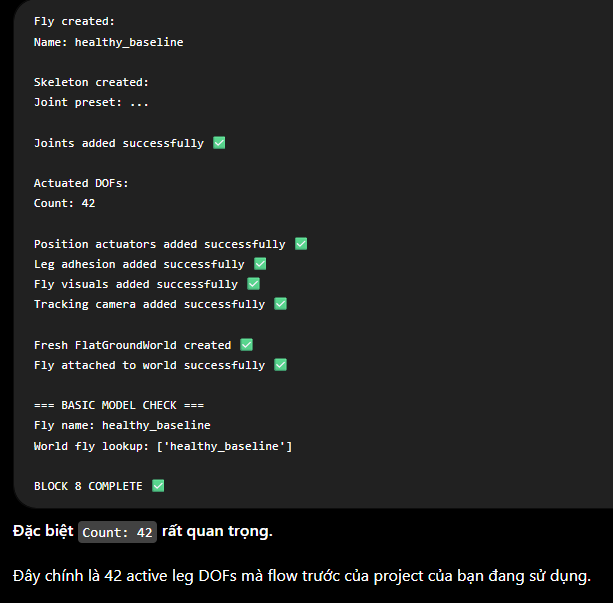

## KIỂM TRA FLY + WORLD

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 8.1
# VALIDATE FLY COMPOSITION
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 8.1")
print("VALIDATING FLY COMPOSITION")
print("=" * 70)


# ------------------------------------------------------------
# FLY
# ------------------------------------------------------------

print("\n=== FLY OBJECT ===")

print("Type   :", type(fly))
print("Class  :", fly.__class__.__name__)
print("Module :", fly.__class__.__module__)
print("Name   :", fly.name)


# ------------------------------------------------------------
# SKELETON
# ------------------------------------------------------------

print("\n=== SKELETON ===")

print(
    "Skeleton exists:",
    "YES ✅" if hasattr(fly, "skeleton") else "NO ❌"
)

if hasattr(fly, "skeleton"):

    print(
        "Skeleton type:",
        type(fly.skeleton)
    )


# ------------------------------------------------------------
# JOINTS / DOFs
# ------------------------------------------------------------

print("\n=== JOINT / DOF CHECK ===")

if hasattr(fly, "skeleton"):

    print(
        "Skeleton DOFs:",
        len(fly.skeleton.joint_dofs)
        if hasattr(fly.skeleton, "joint_dofs")
        else "API-dependent"
    )

    print(
        "Actuated DOFs:",
        len(actuated_dofs)
    )


# ------------------------------------------------------------
# WORLD
# ------------------------------------------------------------

print("\n=== WORLD OBJECT ===")

print("Type   :", type(world))
print("Class  :", world.__class__.__name__)
print("Module :", world.__class__.__module__)


# ------------------------------------------------------------
# FLY LOOKUP
# ------------------------------------------------------------

print("\n=== WORLD FLY LOOKUP ===")

print(
    "Fly lookup keys:",
    list(world.fly_lookup.keys())
)

print(
    "healthy_baseline registered:",
    "YES ✅"
    if "healthy_baseline" in world.fly_lookup
    else "NO ❌"
)


# ------------------------------------------------------------
# MJSPEC
# ------------------------------------------------------------

print("\n=== WORLD MJSPEC ===")

print(
    "world.mjcf_root:",
    type(world.mjcf_root)
)


# ------------------------------------------------------------
# EXPECTED STRUCTURE
# ------------------------------------------------------------

print("\n=== EXPECTED STRUCTURE ===")

print("Fly object              : PASS ✅")
print("Skeleton                : PASS ✅")
print("42 active leg DOFs      :",
      "PASS ✅" if len(actuated_dofs) == 42 else "FAIL ❌")
print("Fly attached to world   :",
      "PASS ✅"
      if "healthy_baseline" in world.fly_lookup
      else "FAIL ❌")


print("\n" + "=" * 70)
print("BLOCK 8.1 COMPLETE ✅")
print("=" * 70)

SESSION 1 — BLOCK 8.1
VALIDATING FLY COMPOSITION

=== FLY OBJECT ===
Type   : <class 'flygym.compose.fly.neuromechfly.NeuroMechFly'>
Class  : NeuroMechFly
Module : flygym.compose.fly.neuromechfly
Name   : healthy_baseline

=== SKELETON ===
Skeleton exists: YES ✅
Skeleton type: <class 'flygym.anatomy.Skeleton'>

=== JOINT / DOF CHECK ===
Skeleton DOFs: API-dependent
Actuated DOFs: 42

=== WORLD OBJECT ===
Type   : <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
Class  : FlatGroundWorld
Module : flygym.compose.world.flat_ground

=== WORLD FLY LOOKUP ===
Fly lookup keys: ['healthy_baseline']
healthy_baseline registered: YES ✅

=== WORLD MJSPEC ===
world.mjcf_root: <class 'mujoco._specs.MjSpec'>

=== EXPECTED STRUCTURE ===
Fly object              : PASS ✅
Skeleton                : PASS ✅
42 active leg DOFs      : PASS ✅
Fly attached to world   : PASS ✅

BLOCK 8.1 COMPLETE ✅


## BLOCK 8.2 — COMPILE MUJOCO ĐÚNG

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 8.2
# DIRECT MUJOCO MODEL COMPILATION CHECK
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 8.2")
print("DIRECT MUJOCO MODEL COMPILATION CHECK")
print("=" * 70)

import mujoco


# ------------------------------------------------------------
# 1. CHECK MJSPEC
# ------------------------------------------------------------

print("\n=== WORLD SPEC ===")

print(
    "world type:",
    type(world)
)

print(
    "world.mjcf_root type:",
    type(world.mjcf_root)
)


# ------------------------------------------------------------
# 2. COMPILE
# ------------------------------------------------------------

print("\n=== COMPILING MJSPEC ===")

try:

    model = world.mjcf_root.compile()

    print(
        "MjSpec compilation: SUCCESS ✅"
    )

except Exception as e:

    print(
        "MjSpec compilation: FAILED ❌"
    )

    print(
        type(e).__name__,
        str(e)
    )

    raise


# ------------------------------------------------------------
# 3. CORE COUNTS
# ------------------------------------------------------------

print("\n=== CORE MUJOCO MODEL COUNTS ===")

print(
    "Number of bodies     :",
    model.nbody
)

print(
    "Number of joints     :",
    model.njnt
)

print(
    "Number of DOFs       :",
    model.nv
)

print(
    "Number of qpos       :",
    model.nq
)

print(
    "Number of actuators  :",
    model.nu
)

print(
    "Number of sensors    :",
    model.nsensor
)


# ------------------------------------------------------------
# 4. VALIDATION
# ------------------------------------------------------------

print("\n=== MODEL SANITY CHECK ===")

checks = {

    "nbody > 1":
        model.nbody > 1,

    "njnt > 0":
        model.njnt > 0,

    "nv > 0":
        model.nv > 0,

    "nq > 0":
        model.nq > 0,

    "nu > 0":
        model.nu > 0,
}


for name, result in checks.items():

    print(
        f"{name:<20}: "
        f"{'PASS ✅' if result else 'FAIL ❌'}"
    )


model_valid = all(checks.values())


print(
    "\nOverall model validity:",
    "VALID ✅"
    if model_valid
    else "INVALID ❌"
)


# ------------------------------------------------------------
# 5. BODY NAMES
# ------------------------------------------------------------

print("\n=== FIRST BODY NAMES ===")

for i in range(min(model.nbody, 15)):

    name = mujoco.mj_id2name(
        model,
        mujoco.mjtObj.mjOBJ_BODY,
        i,
    )

    print(
        f"body[{i:02d}] = {name}"
    )


# ------------------------------------------------------------
# 6. JOINT NAMES
# ------------------------------------------------------------

print("\n=== FIRST JOINTS ===")

for i in range(min(model.njnt, 15)):

    name = mujoco.mj_id2name(
        model,
        mujoco.mjtObj.mjOBJ_JOINT,
        i,
    )

    print(
        f"joint[{i:02d}] = {name}"
    )


# ------------------------------------------------------------
# 7. ACTUATORS
# ------------------------------------------------------------

print("\n=== FIRST ACTUATORS ===")

for i in range(min(model.nu, 15)):

    name = mujoco.mj_id2name(
        model,
        mujoco.mjtObj.mjOBJ_ACTUATOR,
        i,
    )

    print(
        f"actuator[{i:02d}] = {name}"
    )


# ------------------------------------------------------------
# 8. GLOBAL VARIABLE
# ------------------------------------------------------------

compiled_model = model

print("\n=== GLOBAL MODEL ===")

print(
    "compiled_model assigned successfully ✅"
)

print(
    "model type:",
    type(compiled_model)
)


print("\n" + "=" * 70)
print("BLOCK 8.2 COMPLETE ✅")
print("=" * 70)

SESSION 1 — BLOCK 8.2
DIRECT MUJOCO MODEL COMPILATION CHECK

=== WORLD SPEC ===
world type: <class 'flygym.compose.world.flat_ground.FlatGroundWorld'>
world.mjcf_root type: <class 'mujoco._specs.MjSpec'>

=== COMPILING MJSPEC ===
MjSpec compilation: SUCCESS ✅

=== CORE MUJOCO MODEL COUNTS ===
Number of bodies     : 69
Number of joints     : 67
Number of DOFs       : 72
Number of qpos       : 73
Number of actuators  : 48
Number of sensors    : 6

=== MODEL SANITY CHECK ===
nbody > 1           : PASS ✅
njnt > 0            : PASS ✅
nv > 0              : PASS ✅
nq > 0              : PASS ✅
nu > 0              : PASS ✅

Overall model validity: VALID ✅

=== FIRST BODY NAMES ===
body[00] = world
body[01] = healthy_baseline/c_thorax
body[02] = healthy_baseline/c_rostrum
body[03] = healthy_baseline/c_haustellum
body[04] = healthy_baseline/l_eye
body[05] = healthy_baseline/r_eye
body[06] = healthy_baseline/l_pedicel
body[07] = healthy_baseline/l_funiculus
body[08] = healthy_baseline/l_arista
bod

## BLOCK 9 — INSTALL + CHECK GPU

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 9
# INSTALL + CHECK FLYGYM GPU BACKEND
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 9")
print("INSTALLING / CHECKING GPU BACKEND")
print("=" * 70)

import os
import sys

# Headless rendering for Google Colab
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

print("\nInstalling FlyGym 2.1.0 + Warp GPU backend...")

%pip install -q "flygym[warp] @ git+https://github.com/NeLy-EPFL/flygym.git@v2.1.0"

print("\nInstallation command completed ✅")

SESSION 1 — BLOCK 9
INSTALLING / CHECKING GPU BACKEND

Installing FlyGym 2.1.0 + Warp GPU backend...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

Installation command completed ✅


## Block 9.1 - CHECK GPU

In [ ]:
# ============================================================
# SESSION 1 — BLOCK 9.1
# GPU BACKEND CHECK
# ============================================================

print("=" * 70)
print("SESSION 1 — BLOCK 9.1")
print("GPU BACKEND CHECK")
print("=" * 70)

import torch

print("\n=== PYTORCH GPU ===")

print(
    "CUDA available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU count:",
        torch.cuda.device_count()
    )

    print(
        "GPU name:",
        torch.cuda.get_device_name(0)
    )

else:

    print(
        "CUDA GPU: NOT AVAILABLE ❌"
    )


print("\n=== FLYGYM WARP ===")

try:

    from flygym.warp.utils import check_gpu

    print(
        "flygym.warp import: SUCCESS ✅"
    )

    check_gpu()

    print(
        "\nWarp GPU backend: READY ✅"
    )

except Exception as e:

    print(
        "\nWarp GPU backend: FAILED ❌"
    )

    print(
        "Error type:",
        type(e).__name__
    )

    print(
        "Error:",
        str(e)
    )


print("\n" + "=" * 70)
print("BLOCK 9.1 COMPLETE")
print("=" * 70)

SESSION 1 — BLOCK 9.1
GPU BACKEND CHECK

=== PYTORCH GPU ===
CUDA available: True
GPU count: 1
GPU name: Tesla T4

=== FLYGYM WARP ===
flygym.warp import: SUCCESS ✅

Warp GPU backend: READY ✅

BLOCK 9.1 COMPLETE


In [ ]:
# ============================================================
# SESSION 1 — BLOCK 10
# PROJECT DIRECTORY
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/FlyBrain_Parkinson_Project"
)

SESSION_DIR = PROJECT_ROOT / "Session_01_Setup"

PROJECT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

SESSION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("PROJECT DIRECTORY")
print("=" * 70)

print("Project root:")
print(PROJECT_ROOT)

print("\nSession 1 directory:")
print(SESSION_DIR)

print("\nDirectories created successfully ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT DIRECTORY
Project root:
/content/drive/MyDrive/FlyBrain_Parkinson_Project

Session 1 directory:
/content/drive/MyDrive/FlyBrain_Parkinson_Project/Session_01_Setup

Directories created successfully ✅
